In [ ]:
class Demo:
    pass

In [ ]:
type(Demo)

In [ ]:
print(type(Demo))

In [ ]:
print(type(type))

In [ ]:
def func():
    pass


print(type(func))

In [ ]:
func = lambda x: x**2
print(type(func))

In [ ]:
type(func)

In [ ]:
item = Demo()
print(type(item))

In [ ]:
print(type(object))

In [ ]:
print(issubclass(type, object))
# Output: True
# Translation: 'type' inherits from 'object'.

In [ ]:
print(issubclass(Demo, object))
# Output: True

In [ ]:
print(Demo.__bases__)

In [ ]:
print(type.__bases__)

In [ ]:
# These are classes (types)
class PDFReader:
    pass


class CSVReader:
    pass


# You can store TYPES directly in a dictionary!
readers = {"pdf": PDFReader, "csv": CSVReader}

file_type = "csv"
# Python grabs the CSVReader class object and creates an instance of it instantly
my_reader = readers[file_type]()

In [ ]:
type(my_reader)

In [ ]:
def check_data(data, required_type):
    if not isinstance(data, required_type):
        print(f"Error: Expected a {required_type.__name__}!")


# Passing the actual 'int' and 'str' types as arguments
check_data(100, int)
check_data("Hello", str)
check_data("Hello", int)

In [ ]:
class Dog:
    def speak(self):
        return "Woof!"


class Cat:
    def speak(self):
        return "Meow!"


# This function expects a CLASS, not an object
def spawn_animal(animal_class):
    # It adds () to build the object dynamically inside the function
    new_animal = animal_class()
    print(new_animal.speak())


# Passing the raw blueprints directly
spawn_animal(Dog)  # Output: Woof!
spawn_animal(Cat)  # Output: Meow!

In [ ]:
# Storing the actual classes in a list
blueprints = [Dog, Cat]

# Grab the second blueprint (Cat) and build it on the same line
my_pet = blueprints[1]()

print(my_pet.speak())  # Output: Meow!

In [ ]:
# A simple "Workflow Creator" (Metaprogramming)
def workflow_factory(name):
    # This creates a brand new class on the fly!
    return type(name, (object,), {"run": lambda self: f"Running {name}..."})


# Now you have a factory that spits out custom classes
BackupWorkflow = workflow_factory("Backup")
EmailWorkflow = workflow_factory("Email")

print(BackupWorkflow().run())  # Output: Running Backup...

In [ ]:
id(type)

In [ ]:
print(issubclass(object, object))
# Output: True

In [ ]:
print(issubclass(Demo, Demo))
# Output: True

In [ ]:
type(object)

In [ ]:
print(type(object))

In [ ]:
Dog = type("Dog", (object,), {"speak": lambda self: "Woof!"})

In [ ]:
print(type(Dog))

In [ ]:
tommy = Dog()
print(tommy.speak())

The "Tag" vs. The "Object"
Dog (The variable): This is just a label (a reference) in your current scope that points to an object in memory.

"Canine" (The class name): This is metadata inside the object itself.

In [ ]:
# The internal name is "Canine", but the variable name is "Dog"
Dog = type("Canine", (object,), {"speak": lambda self: "Woof!"})

# See the difference:
print(Dog)  # Output: <class '__main__.Canine'>
print(Dog.__name__)  # Output: Canine

In [ ]:
# 'species' is a CLASS ATTRIBUTE
Dog = type("Dog", (object,), {"species": "Canine"})

d1 = Dog()
d2 = Dog()

print(d1.species)  # Output: Canine
print(d2.species)  # Output: Canine

In [ ]:
def my_init(self, name):
    self.name = name  # 'name' is an INSTANCE ATTRIBUTE


Dog = type("Dog", (object,), {"__init__": my_init})

d1 = Dog("Buddy")
d2 = Dog("Max")

print(d1.name)  # Output: Buddy
print(d2.name)  # Output: Max

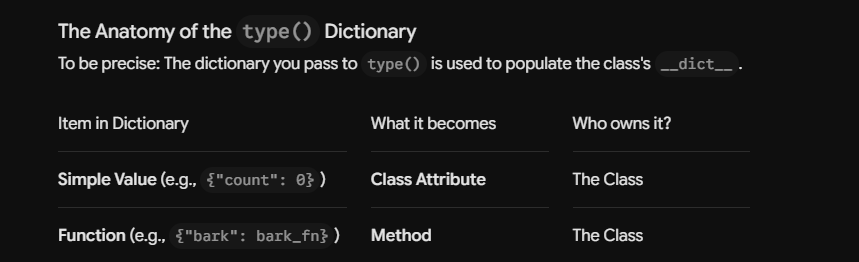

In [ ]:
def my_init(self, x, y):
    self.x = x  # These create the unique instance attributes
    self.y = y


# The class blueprint
Point = type("Point", (object,), {"__init__": my_init})

# Usage
p = Point(10, 20)
print(p.x)  # It just works. No _x, no property, no magic.

In [ ]:
def my_init(self, x, y):
    self.x = x
    self.y = y


Point = type("Point", (object,), {"__init__": my_init})

p = Point(10, 20)
p.x = 99  # This WORKS perfectly! The value is now 99.

In [ ]:
p.x

In [1]:
from abc import ABCMeta


class Point(metaclass=ABCMeta):
    x = 10

"In Python, the class keyword is syntactic sugar for Metaclass Instantiation. For standard classes, the default metaclass is type, meaning the class block effectively resolves to a type(name, bases, namespace) call. However, if a custom metaclass is defined, the class keyword delegates the creation to that specific metaclass instead of type."

In Python, the class keyword is just "syntactic sugar" for type() unless metaclass specified expolicitly like above example:

When you write this:

In [2]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

Python translates it into the exact same internal mechanics as:

In [3]:
def __init__(self, x, y):
    self.x = x
    self.y = y


Point = type("Point", (object,), {"__init__": __init__})

The Three Ingredients of class
When the Python interpreter sees the class keyword, it grabs those three things you noticed:

The Name: The string after class becomes the first argument to type().

The Base Classes: The tuple in parentheses after the name becomes the second argument to type().

The Body: It executes all the code inside the class block, collects all the functions and variables into a dictionary, and passes that as the third argument to type().

Why does Python have the class keyword?
If type() does everything, why bother with class?
Readability.

Imagine if you had to build a complex class with 10 methods and inheritance using type() and dictionaries—your code would be a nightmare to read. The class keyword allows you to structure that logic visually, but under the hood, it is 100% building a class object using the type function.

You have effectively stripped away the "magic" of Python's object-oriented system. The class keyword is literally just a helper function that calls type() for you.

The Edge Cases (Where it gets weird)
If you are auditing a system, these are the traps you look for:

1. Circular References (The Memory Leak Trap)
What happens if Object A points to Object B, and Object B points back to Object A?
If you delete the external variables pointing to them, their Reference Counts drop, but they only drop to 1 (because they are still holding onto each other).

The Fix: Python has a secondary "Generational Garbage Collector" that occasionally sweeps through memory specifically looking for isolated islands of objects pointing at each other. It forcefully breaks the loop and deletes them.

2. The Singleton Pattern (Hijacking __new__)
You can write a custom __new__ that remembers the first memory address it allocates. If someone tries to create a second object, __new__ just returns the first memory address again instead of asking for new RAM. Every variable ends up pointing to the exact same object.

3. __slots__ (Killing the Dictionary)
If you create a class and define __slots__ = ['name'], Python will completely refuse to create a __dict__ for the object in Step 3. It will allocate exact memory slots just like a tuple, but unlike a tuple, it allows __init__ to overwrite the values in those slots. This is how you get the speed/memory of a tuple with the mutability of a standard object.

To help you visualize this, I've generated an interactive memory simulator. You can spawn an object, attach references, and watch exactly how the C-engine tracks the memory and destroys it when the count hits zero.

In [1]:
class Player:
    def run(self):
        return self

In [2]:
p1 = Player()

In [3]:
print(p1)

In [4]:
print(p1.run())

In [5]:
p1 is p1.run()

True

In [9]:
p1 is p1.run().run()

True

In [8]:
print(p1.run().run())

In [10]:
p1

In [11]:
p1.run().run()